In [ ]:
!pip install -e relatipy==0.3.2

Obtaining file:///Users/ldiaz/Documents/Documentos/otros/relatipy
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for relatipy (pyproject.toml) ... done
  Created wheel for relatipy: filename=relatipy-0.3.2-0.editable-py3-none-any.whl size=2087 sha256=7879dadd8a1a786be86f3ae3dcab42483ee23e71f3e5133152ad076e618bf8a8
  Stored in directory: /private/var/folders/8g/jy3rvzr50kv5w6g24cxmq6kc0000gp/T/pip-ephem-wheel-cache-cxtvi65v/wheels/54/56/7b/7f88fd2a34a85deeb07d9ebdc43f856b013db761c7c7e4acd6
Successfully built relatipy
  Attempting uninstall: relatipy
    Found existing installation: relatipy 0.3.2
    Uninstalling relatipy-0.3.2:
      Successfully uninstalled relatipy-0.3.2


# Mejorar la primer entrega 

## Conservación de la magnitud del cuadrimomento

In [2]:
import importlib
import relatipy
importlib.reload(relatipy)
import relatipy.numeric as rn

import numpy as np
import matplotlib.pyplot as plt

In [3]:
mass = 1
schwarzschild = rn.metrics.Schwarzschild(mass=mass)
kerr = rn.metrics.Kerr(mass=mass, a=0.5)

R_s = schwarzschild.R_s
R_s

2.0

In [4]:
x1 = 4*R_s
ic = rn.coordinates.Spherical(xs=[0, x1, np.pi/2, 0], vels=[ 0, 0, np.sqrt(1/x1)])
ic.convert_to("OrbitalElements",mass=mass).state_vector


array([0.00000000e+00, 8.00000000e+00, 2.81565218e-16, 0.00000000e+00,
       0.00000000e+00, 6.12323400e-17, 0.00000000e+00])

In [5]:
from relatipy.numeric.constants import _L_ref

x1_SI = 1e10  # metros
x1 = 4*R_s

ic = rn.coordinates.OrbitalElements(
    t=0,
    a=x1,
    e=0.,
    inc=0.,
    Omega=0.,
    omega=0.,
    f=0.,
    mass=1.0,  # 1 masa solar geom
)

print(ic.convert_to("BoyerLindquist", a=kerr.a).state_vector)

P = 2*np.pi*x1**(3/2)
taus = np.linspace(0, 100*P, 10000)
path = kerr.geodesic.get_path(ic, taus)

from relatipy.visualization._3D.plot_black_hole import PlotKerr

plot = PlotKerr(kerr)
plot.add_path(path, label="orbit")
plot.plot().show()

[ 0.          7.98435971  1.57079633  0.          0.         -0.
  0.35355339]


/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


In [6]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
# conjunto de integradores de solve_ivp
integrators = [
    "RK45",
    "RK23",
    "DOP853",
    "Radau",
    "BDF",
    "LSODA",
]

paths = {}

taus = np.linspace(0, 500*P, 10000)

for integrator in integrators:
    paths[integrator] = kerr.geodesic.get_path(ic, taus, integrator=integrator).convert_to("BoyerLindquist", a=kerr.a)

Q_base = paths["RK45"]._get_Q(kerr)[0]

/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


In [7]:
# from relatipy.visualization._2D import SciSubplot
# workspace = SciSubplot()

# fig, ax = workspace.fig, workspace.ax

# # Base line
# ax.plot(taus, np.ones_like(taus) * Q_base, "--", color="black")

# # ax.plot(taus, abs((paths["RK23"]._get_Q(kerr) - Q_base)/Q_base))
# # ax.plot(taus, abs((paths["DOP853"]._get_Q(kerr) - Q_base)/Q_base))
# # ax.plot(taus, abs((paths["Radau"]._get_Q(kerr) - Q_base)/Q_base))
# # ax.plot(taus, abs((paths["BDF"]._get_Q(kerr) - Q_base)/Q_base))



# ax.set_yscale("log")

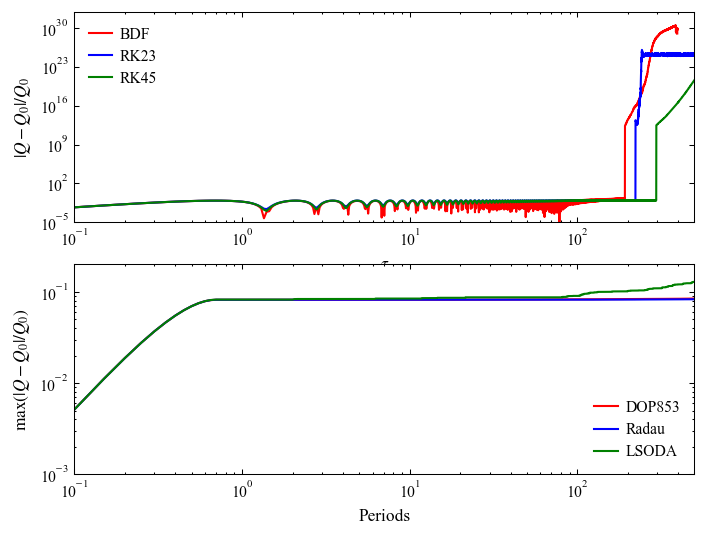

In [8]:
import numpy as np
from relatipy.visualization._2D import SciSubplot
colors = ["red", "blue", "green", "purple", "orange", "brown", "pink", "gray", "black"]

eps = 1e-16

# ── Panel 1 : error instantáneo ─────────────────────────────
workspace1 = SciSubplot(subplot=(2,1))
fig1, axs = workspace1.fig, workspace1.axs
ax1 = axs[0]
ax2 = axs[1]
methods = ["BDF", "RK23", "RK45"]
for i, method in enumerate(methods):

    Q = paths[method]._get_Q(kerr)
    err = np.abs((Q - Q_base) / Q_base) + eps

    proper_taus = taus[:len(err)]/P
    ax1.plot(proper_taus, err, label=method, color=colors[i])

ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_xlabel(r"$\tau$")
ax1.set_ylabel(r"$|Q-Q_0|/Q_0$")
ax1.set_ylim(1e-5)
ax1.set_xlim(1e-1, max(taus/P))
ax1.legend()


# ── Panel 2 : error máximo acumulado ─────────────────────────

methods = ["DOP853", "Radau", "LSODA"]
for i, method in enumerate(methods):

    Q = paths[method]._get_Q(kerr)
    err = np.abs((Q - Q_base) / Q_base) + eps
    err_max = np.maximum.accumulate(err)

    proper_taus = taus[:len(err_max)]/P
    ax2.plot(proper_taus, err_max, label=method, color=colors[i])

ax2.set_yscale("log")
ax2.set_xscale("log")
ax2.set_xlabel(r"Periods")
ax2.set_ylabel(r"$\max(|Q-Q_0|/Q_0)$")
ax2.set_ylim(1e-3, 2e-1)
ax2.set_xlim(1e-1, max(taus/P))

ax2.legend()

plt.draw()
plt.savefig("../figures/002-integradores_de_orbitas/error_instantaneous.png")


In [9]:
# good_methods = ["DOP853", "Radau", "LSODA"]

# good_paths = {}

# taus_2 = np.linspace(0, 10000*P, 30000)

# for integrator in good_methods:
#     good_paths[integrator] = kerr.geodesic.get_path(ic, taus_2, integrator=integrator).convert_to("BoyerLindquist", a=kerr.a)



NameError: name 'good_methods' is not defined

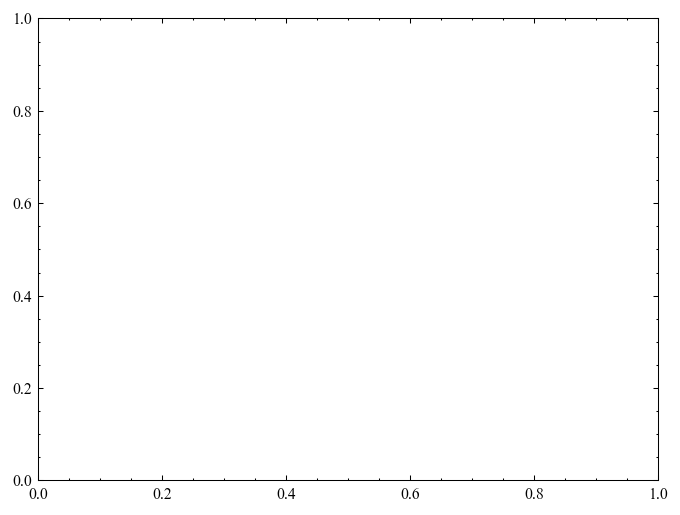

In [10]:
eps = 1e-16

# ── Panel 1 : error instantáneo ─────────────────────────────
workspace1 = SciSubplot()
fig1, ax = workspace1.fig, workspace1.ax


for i, method in enumerate(good_methods):

    Q = good_paths[method]._get_Q(kerr)
    err = np.abs((Q - Q_base) / Q_base) + eps
    err_max = np.maximum.accumulate(err)

    proper_taus = taus_2[:len(err_max)]/P
    ax.plot(proper_taus, err_max, label=method, color=colors[i])

ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$|Q-Q_0|/Q_0$")
ax.set_ylim(5e-3)
ax.set_xlim(1e-1, max(taus_2/P))
ax.legend()

plt.draw()
plt.savefig("../figures/002-integradores_de_orbitas/error_instantaneous_DOP853_Radau_LSODA.png")


In [ ]:
from relatipy.visualization._3D.plot_black_hole import PlotKerr

plot = PlotKerr(kerr)
plot.add_path(paths["Radau"], label="orbit")
plot.plot().show()

# save plotly
# plot.plot().write_html("../figures/002-integradores_de_orbitas/orbit_500_periods.html")

In [ ]:
import os
recalculate = False

ic_bl = ic.convert_to("BoyerLindquist", a=kerr.a)

if not os.path.exists("../save/Qs_radau.npy") or recalculate:
    n_divisions = np.logspace(1, 4, 10, dtype=int)
    n_periods = np.logspace(0, 4, 10)


    Qs = np.zeros((len(n_divisions), len(n_periods)))
    paths = []
    # Se puede paralelizar usando joblib (o también concurrent.futures, pero joblib es cómodo para numpy).
    # Aquí el anidamiento tiene un detalle: la iteración (i_period, i_div) depende de un grid ("mesh") 2D.
    # Usamos joblib.Parallel para computar cada (i_period, i_div) en paralelo y luego reconstruimos Qs y paths.

    from joblib import Parallel, delayed

    def compute_Qs(i_period, i_div):
        period = n_periods[i_period]
        n_div = n_divisions[i_div]
        taus = np.linspace(0, period*P, n_div)
        print(f"Period: {period/P}, Divisions: {n_div}")
        path = kerr.geodesic.get_path(ic_bl, taus, integrator="Radau")
        Q = path._get_Q(kerr)
        err = np.abs((Q - Q_base) / Q_base) + eps
        err_max = np.maximum.accumulate(err)
        return (i_div, i_period, path, err_max[-1])

    # Creamos todas las combinaciones (i_period, i_div)
    combinations = [
        (i_period, i_div)
        for i_period in range(len(n_periods))
        for i_div in range(len(n_divisions))
    ]

    # El argumento n_jobs indica cuántos procesos paralelos quieres ejecutar.
    # Por ejemplo, n_jobs=2 usa 2 CPU cores; n_jobs=-1 usa todos los cores disponibles.
    # Puedes cambiarlo según la capacidad de tu computador y cuánto quieres paralelizar.
    results = Parallel(n_jobs=-1)(
        delayed(compute_Qs)(i_period, i_div) for (i_period, i_div) in combinations
    )

    # Restauramos los arrays en orden
    paths = []
    for (i_div, i_period, path, q_val) in results:
        Qs[i_div, i_period] = q_val
        paths.append(path)


    # guardamos como numpy array "../save/Qs_radau.npy"
    np.save("../save/Qs_radau.npy", Qs)


In [ ]:
# np.save("../save/paths_radau.npy", np.array([ path.state_vector for path in paths]))
np.save("../save/Qs_radau.npy", Qs)

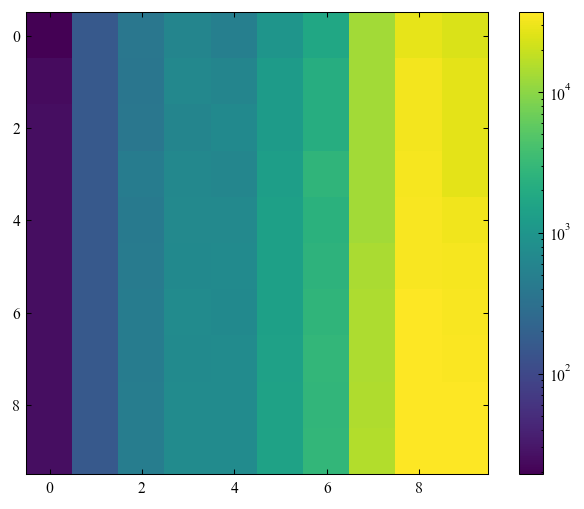

In [ ]:
# graficamos como imagen muy sensible a los colores
# log scale
from matplotlib.colors import LogNorm
plt.imshow(Qs, cmap="viridis", norm=LogNorm())
plt.colorbar()
plt.show()
